## Consumer Sentiment vs Consumer Consumption

### Preparation
---

#### Import statements

In [82]:
import pandas as pd
import matplotlib.pyplot as plt
import matplotlib.dates as mdates

import numpy as np
import scipy.stats as stats



pd.options.display.float_format ="{:,.2f}".format

#### Load the Datasets

In [83]:
consumer_sentiment_df = pd.read_csv("./Datasets/UMCSENT.csv")
consumer_economic_conditions_df= pd.read_excel("./Datasets/Current_Economic_Conditions.xlsx")
consumer_expectations_df= pd.read_excel("./Datasets/Consumer_Expectations.xlsx")
personal_consumption_exp_unadjusted = pd.read_csv("./Datasets/ND000349Q.csv")

### Initial checks
---

Use of the data is from 2000 onwards - so go to excel and remove the earlier values for ease.

<section class="data-checks">

  <h5>First Set of Checks</h5>
  <ul>
    <li>Head</li>
    <li>Tail</li>
    <li>Datatypes</li>
    <li>Columns</li>
    <li>Shape</li>
  </ul>

  <h5>Second Set of Checks</h5>
  <ul>
    <li>Remove unused columns</li>
    <li>Check duplicate values</li>
    <li>Missing values</li>
  </ul>
</section>


#### Consumer sentiment checks (Overall Sentiment)

In [84]:
#### first set of checks
consumer_sentiment_df.sample(5)         # Date is not the index - np
consumer_sentiment_df.head()            # Starts at the correct date
consumer_sentiment_df.tail()            # ends at 2026-01
consumer_sentiment_df.columns           # No spaces which is good but do need to rename  + No need to drop columns
consumer_sentiment_df.dtypes            # Observation date needs to be converted

    #### Initial adjustments
consumer_sentiment_df.rename(columns={"observation_date":"Date","UMCSENT":"Sentiment_index"}, inplace=True)     # Fixed the index
consumer_sentiment_df["Date"]= pd.to_datetime(consumer_sentiment_df["Date"], format ="%d/%m/%Y")               # Datetime conversion but it is alsop in daily format so convert to thrifst of the mont



#### Second set of checks
consumer_sentiment_df.columns           #No need to drop columns
consumer_sentiment_df.duplicated(subset="Date", keep=False).value_counts()      # All are false so no duplicated values
consumer_sentiment_df.isna().sum()                                              # No missing values for any of the dates + Need to check if all the 12 months are there in the dataset

        # Checks to make sure that all the dates are there for the period from 2000 to 2026.
print(pd.date_range(start= "2000-01-01", end = "2026-01-01", freq="MS").difference(consumer_sentiment_df["Date"]))
                    # Sets up a date range, looks at the month start, then compares and then prints the ones that are different
                    ## There are no missing values

consumer_sentiment_df

DatetimeIndex([], dtype='datetime64[us]', freq='MS')


,Date,Sentiment_index
0,2000-01-01,112.00
1,2000-02-01,111.30
2,2000-03-01,107.10
3,2000-04-01,109.20
4,2000-05-01,110.70
...,...,...
308,2025-09-01,55.10
309,2025-10-01,53.60
310,2025-11-01,51.00
311,2025-12-01,52.90


#### Consumer Expectations checks

In [85]:
#### first set of checks
consumer_expectations_df.sample(5)
consumer_expectations_df.head(30)       # Starts at the correct date
consumer_expectations_df.tail()         # ends at 2026-01
consumer_expectations_df.dtypes          # Observation no need to be converted since its a datetime.
consumer_expectations_df.columns        # No spaces which is good but do need to rename  + No need to drop columns

    #### Initial adjustments
consumer_expectations_df.rename(columns={"Datemy":"Date","ICE":"Consumer_Expectations_index"}, inplace=True)     # Fixed the index

#### Second set of checks
consumer_expectations_df.columns           #Need to remove the recessions column

consumer_expectations_df.duplicated(subset="Date", keep=False).value_counts()      # All are false so no duplicated values
consumer_expectations_df.isna().sum()                                              # No missing values for any of the dates + Need to check if all the 12 months are there in the dataset

        # Checks to make sure that all the dates are there for the period from 2000 to 2026.
print(pd.date_range(start= "2000-01-01", end = "2026-01-01", freq="MS").difference(consumer_expectations_df["Date"]))
                    # Sets up a date range, looks at the month start, then compares and then prints the ones that are different
                    # There are no missing values( from geeks for geeeks)

    #### Adjustments
consumer_expectations_df.drop(columns=["RECESSION"], inplace=True)          ## Remove the recession column
consumer_expectations_df["Date"]= pd.to_datetime(consumer_expectations_df["Date"])
consumer_expectations_df


DatetimeIndex([], dtype='datetime64[us]', freq='MS')


,Date,Consumer_Expectations_index
0,2000-01-01,103.60
1,2000-02-01,105.80
2,2000-03-01,106.00
3,2000-04-01,104.40
4,2000-05-01,103.40
...,...,...
309,2025-10-01,52.60
310,2025-11-01,51.00
311,2025-12-01,52.00
312,2026-01-01,54.20


#### Consumer Economic Conditions checks

In [86]:
#### first set of checks
consumer_economic_conditions_df.sample(5)         # Date is not the index - np
consumer_economic_conditions_df.head()            # Starts at the correct date
consumer_economic_conditions_df.tail()            # ends at 2026-02
consumer_economic_conditions_df.columns           # No spaces which is good but do need to rename  + No need to drop columns
consumer_economic_conditions_df.dtypes            # Npo changes needed

    #### Initial adjustments
consumer_economic_conditions_df.rename(columns={"Unnamed: 0":"Date","3mma":"Economic_Conditions_index"}, inplace=True)     # Fixed the index


#### Second set of checks
consumer_economic_conditions_df.columns           #Need to drop the recessions column
consumer_economic_conditions_df.duplicated(subset="Date", keep=False).value_counts()      # All are false so no duplicated values
consumer_economic_conditions_df.isna().sum()                                              # No missing values for any of the dates+ missing for recession + Need to check if all the 12 months are there

    # Adjustments
consumer_economic_conditions_df.drop(columns=["Recession"], inplace=True)       # Remove the Recession column
consumer_economic_conditions_df["Date"]= pd.to_datetime(consumer_economic_conditions_df["Date"])



        # Checks to make sure that all the dates are there for the period from 2000 to 2026.
print(pd.date_range(start= "2000-01-01", end = "2026-01-01", freq="MS").difference(consumer_economic_conditions_df["Date"]))
                    # Sets up a date range, looks at the month start, then compares and then prints the ones that are different
                    ## There are no missing values
consumer_economic_conditions_df

DatetimeIndex([], dtype='datetime64[us]', freq='MS')


,Date,Economic_Conditions_index
0,2000-01-01,115.40
1,2000-02-01,115.40
2,2000-03-01,116.50
3,2000-04-01,116.70
4,2000-05-01,117.70
...,...,...
309,2025-10-01,60.20
310,2025-11-01,56.70
311,2025-12-01,53.40
312,2026-01-01,52.30


#### Personal Consumption Expenditures - Quarterly - Not adjusted

In [87]:
#### Initial checks
personal_consumption_exp_unadjusted.sample(5)
personal_consumption_exp_unadjusted.head()          ## its months 1,4,7,10  from 2002
personal_consumption_exp_unadjusted.tail()          ## Until 2025
personal_consumption_exp_unadjusted.columns         ## Need to change the names
personal_consumption_exp_unadjusted.dtypes          ## Need to change the observation dates and the floats

        ## Initial adjustments
personal_consumption_exp_unadjusted.rename(columns = {"observation_date":"Date" ,
                                                      "ND000349Q":"Consumption_Expenditures"}, inplace=True)
personal_consumption_exp_unadjusted["Date"] =pd.to_datetime(personal_consumption_exp_unadjusted["Date"])


#### Second set of checks
        # Duplicated values
personal_consumption_exp_unadjusted["Date"].duplicated().value_counts()     # No duplicated columns

        # Missing values
personal_consumption_exp_unadjusted.isna().sum()                            ## No missing values

        # No need to drop columns


## Checks to see if all the dates are there:
print(pd.date_range(start= "2000-01-01", end = "2026-01-01", freq="QS").difference(personal_consumption_exp_unadjusted["Date"]))            ### 2000 , 2001 and 2006 is missing.


DatetimeIndex(['2000-01-01', '2000-04-01', '2000-07-01', '2000-10-01',
               '2001-01-01', '2001-04-01', '2001-07-01', '2001-10-01',
               '2026-01-01'],
              dtype='datetime64[us]', freq=None)


### Main Clean dataset with all variables
---

In [88]:
        ## Merged dataset

## Create the full dataset from 2000-2025  using the quarters
dataset = pd.DataFrame({"Date":pd.date_range(start= "2000-01-01", end = "2026-01-01", freq="QS")})

## Merging all the sentiment dates to this dates
merged_df1 = pd.merge(dataset, consumer_sentiment_df, on="Date", how="left")
merged_df2 =pd.merge(merged_df1, consumer_expectations_df, on="Date", how= "left" )
merged_df3 = pd.merge(merged_df2, consumer_economic_conditions_df, on="Date", how = "left")
merged_df = pd.merge(merged_df3, personal_consumption_exp_unadjusted, on="Date", how="left" )

## Created a merged dataset  and checked to see if there are any missing values
merged_df.isna().sum()             # Missing data for the expenditures, consistent with quarterly data  . Now need to apply interpolation


##  Adding a column for the percentage change from the previous quarter data
merged_df["Pct_Change"]= merged_df["Consumption_Expenditures"].pct_change()*100        ## Skips 3 to get quarterly data

## Doing it quarterly because its easier
merged_df

,Date,Sentiment_index,Consumer_Expectations_index,Economic_Conditions_index,Consumption_Expenditures,Pct_Change
0,2000-01-01,112.00,103.60,115.40,NaN,NaN
1,2000-04-01,109.20,104.40,116.70,NaN,NaN
2,2000-07-01,108.30,103.40,116.40,NaN,NaN
3,2000-10-01,105.80,102.70,112.70,NaN,NaN
4,2001-01-01,94.70,92.90,111.70,NaN,NaN
...,...,...,...,...,...,...
100,2025-01-01,71.70,73.20,71.40,"3,967.13",-5.28
101,2025-04-01,52.20,54.60,63.10,"4,110.69",3.62
102,2025-07-01,61.70,54.60,63.90,"4,138.10",0.67
103,2025-10-01,53.60,52.60,60.20,"4,278.86",3.40


### Descriptive statistics
---

In [89]:
merged_df.describe()

,Date,Sentiment_index,Consumer_Expectations_index,Economic_Conditions_index,Consumption_Expenditures,Pct_Change
count,105,105.00,105.00,105.00,96.00,95.00
mean,2012-12-30 20:48:00,82.02,75.34,92.29,"3,147.71",0.70
min,2000-01-01 00:00:00,51.50,49.60,52.30,"2,330.10",-7.00
25%,2006-07-01 00:00:00,71.70,67.20,79.90,"2,791.98",-2.19
50%,2013-01-01 00:00:00,82.70,76.20,96.60,"3,019.01",1.51
75%,2019-07-01 00:00:00,93.10,85.40,106.30,"3,475.07",3.47
max,2026-01-01 00:00:00,112.00,104.40,117.00,"4,278.86",8.42
std,NaN,14.09,12.36,17.07,495.19,3.50


### Visualisation
---

##### Overall Sentiment to Overall Consumption

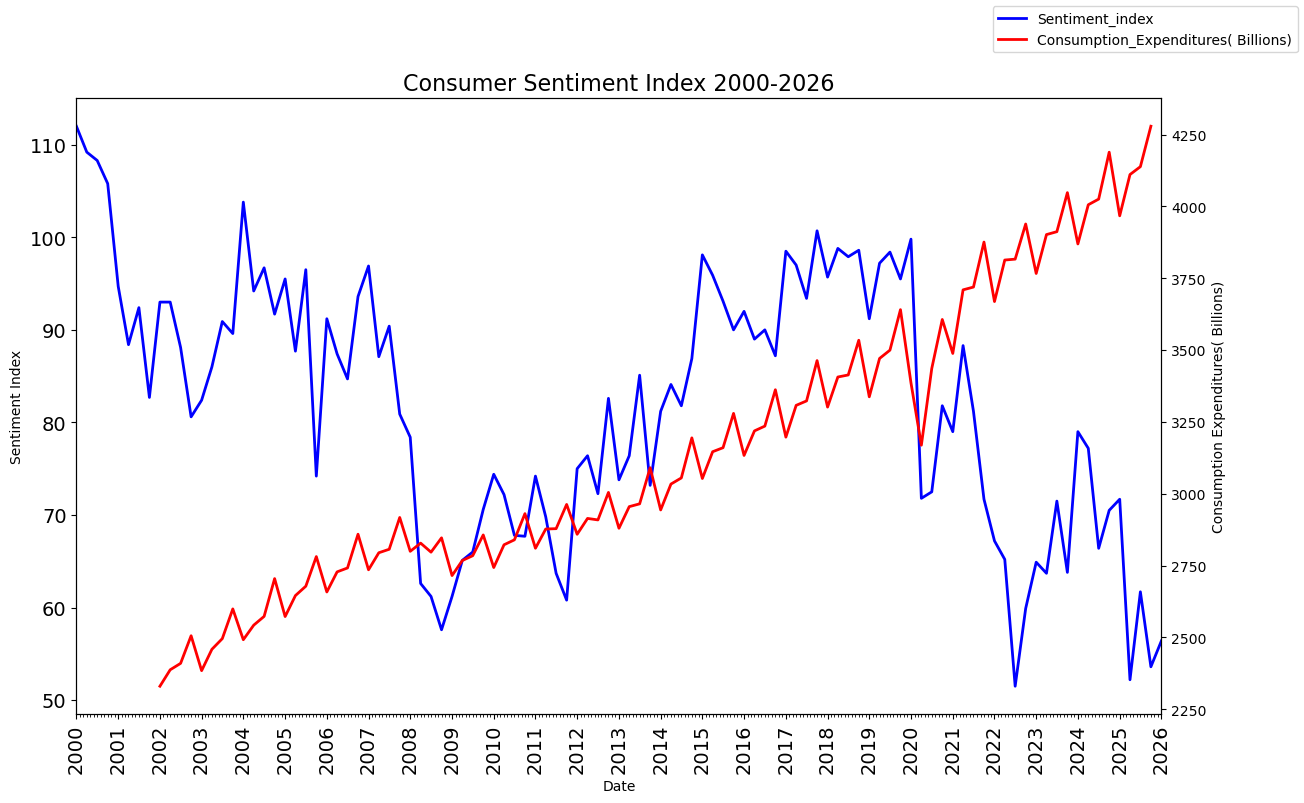

In [90]:
## Plot
    ## Initial features
plt.figure(figsize=(14,8))
plt.xticks(fontsize=14, rotation = 90)
plt.yticks(fontsize=14)

ax1 = plt.gca()
ax2 = ax1.twinx()
    ## Plots
ax1.plot(merged_df["Date"],
         merged_df["Sentiment_index"],
         color="Blue",
         linewidth=2,
         label="Sentiment_index")

ax2.plot(merged_df["Date"],
         merged_df["Consumption_Expenditures"],
         color="Red",
         linewidth=2,
         label="Consumption_Expenditures( Billions)")

    ## Adding in the date functionalities
Year = mdates.YearLocator()
Months = mdates.MonthLocator()
Years_FMT = mdates.DateFormatter('%Y')

ax1.xaxis.set_major_locator(Year)
ax1.xaxis.set_minor_locator(Months)
ax1.xaxis.set_major_formatter(Years_FMT)


    ## Final features

ax1.set_xlabel("Date")
ax1.set_ylabel("Sentiment Index")
ax2.set_ylabel("Consumption Expenditures( Billions)")
plt.title("Consumer Sentiment Index 2000-2026", fontsize=16)
plt.xlim(pd.Timestamp("2000-01-01"), pd.Timestamp("2026-01-01"))
fig = plt.gcf()
fig.legend()
plt.show()


Consumption is steadily rising compared to sentiment -- so the variables seem decoupled. Try the percent changes.


What about growth rates of consumption ?


##### Sentiment to Percentage change in consumption

Text(0, 0.5, 'Consumption Percentage Changes')

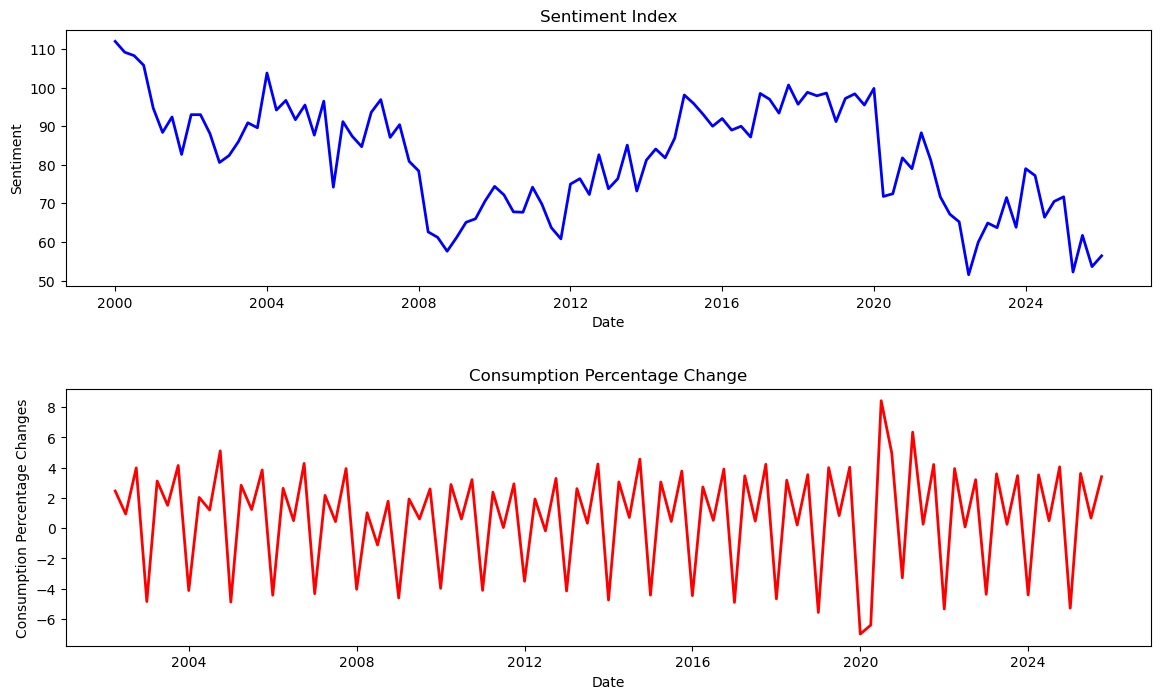

In [91]:
## Plot

plt.figure(figsize=(14,8))


plt.subplot(2, 1, 1)
plt.plot(merged_df["Date"],
         merged_df["Sentiment_index"],
         color="Blue",
         linewidth=2,
         label="Sentiment_index")
plt.title('Sentiment Index')
plt.xlabel('Date')
plt.ylabel('Sentiment')


plt.subplots_adjust(hspace=0.4)  # vertical gap (height)


plt.subplot(2, 1, 2)
plt.plot(merged_df["Date"],
         merged_df["Pct_Change"],
         color="red",
         linewidth=2,
         label="Sentiment_index",
         )
plt.title('Consumption Percentage Change')
plt.xlabel('Date')
plt.ylabel('Consumption Percentage Changes')


##### Percentage change in consumption onto Consumer Economic Conditions + Consumer Expectations( Monthly consumption data)

Text(0, 0.5, 'Consumption Percent Change')

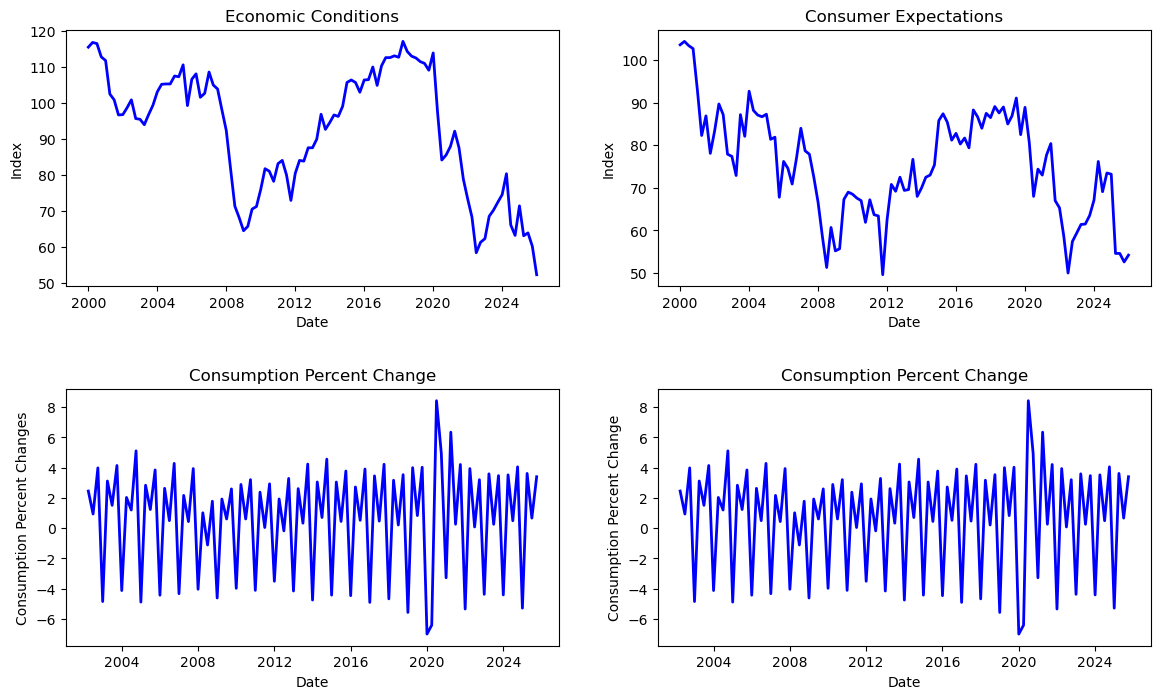

In [96]:
## Plot

plt.figure(figsize=(14,8))


plt.subplot(2, 2, 1)
plt.plot(merged_df["Date"],
         merged_df["Economic_Conditions_index"],
         color="Blue",
         linewidth=2,
         label="Economic Conditions")
plt.title('Economic Conditions')
plt.xlabel('Date')
plt.ylabel('Index')

plt.subplot(2, 2, 2)
plt.plot(merged_df["Date"],
         merged_df["Consumer_Expectations_index"],
         color="Blue",
         linewidth=2,
         label="Consumer Expectations")
plt.title('Consumer Expectations')
plt.xlabel('Date')
plt.ylabel('Index')


plt.subplots_adjust(hspace=0.4)  # vertical gap (height)


plt.subplot(2, 2, 3)

plt.plot(merged_df["Date"],
         merged_df["Pct_Change"],
         color="Blue",
         linewidth=2,
         label="Sentiment_index")
plt.title('Consumption Percent Change')
plt.xlabel('Date')
plt.ylabel('Consumption Percent Changes')

plt.subplot(2, 2, 4)
plt.plot(merged_df["Date"],
         merged_df["Pct_Change"],
         color="Blue",
         linewidth=2,
         label="Sentiment_index")
plt.title('Consumption Percent Change')
plt.xlabel('Date')
plt.ylabel('Consumption Percent Change')

##### Consumer Economic Conditions vs Consumer Expectations

C:\Users\mathe\AppData\Local\Temp\ipykernel_16916\1942263292.py:41: UserWarning: FigureCanvasAgg is non-interactive, and thus cannot be shown
  fig.show()


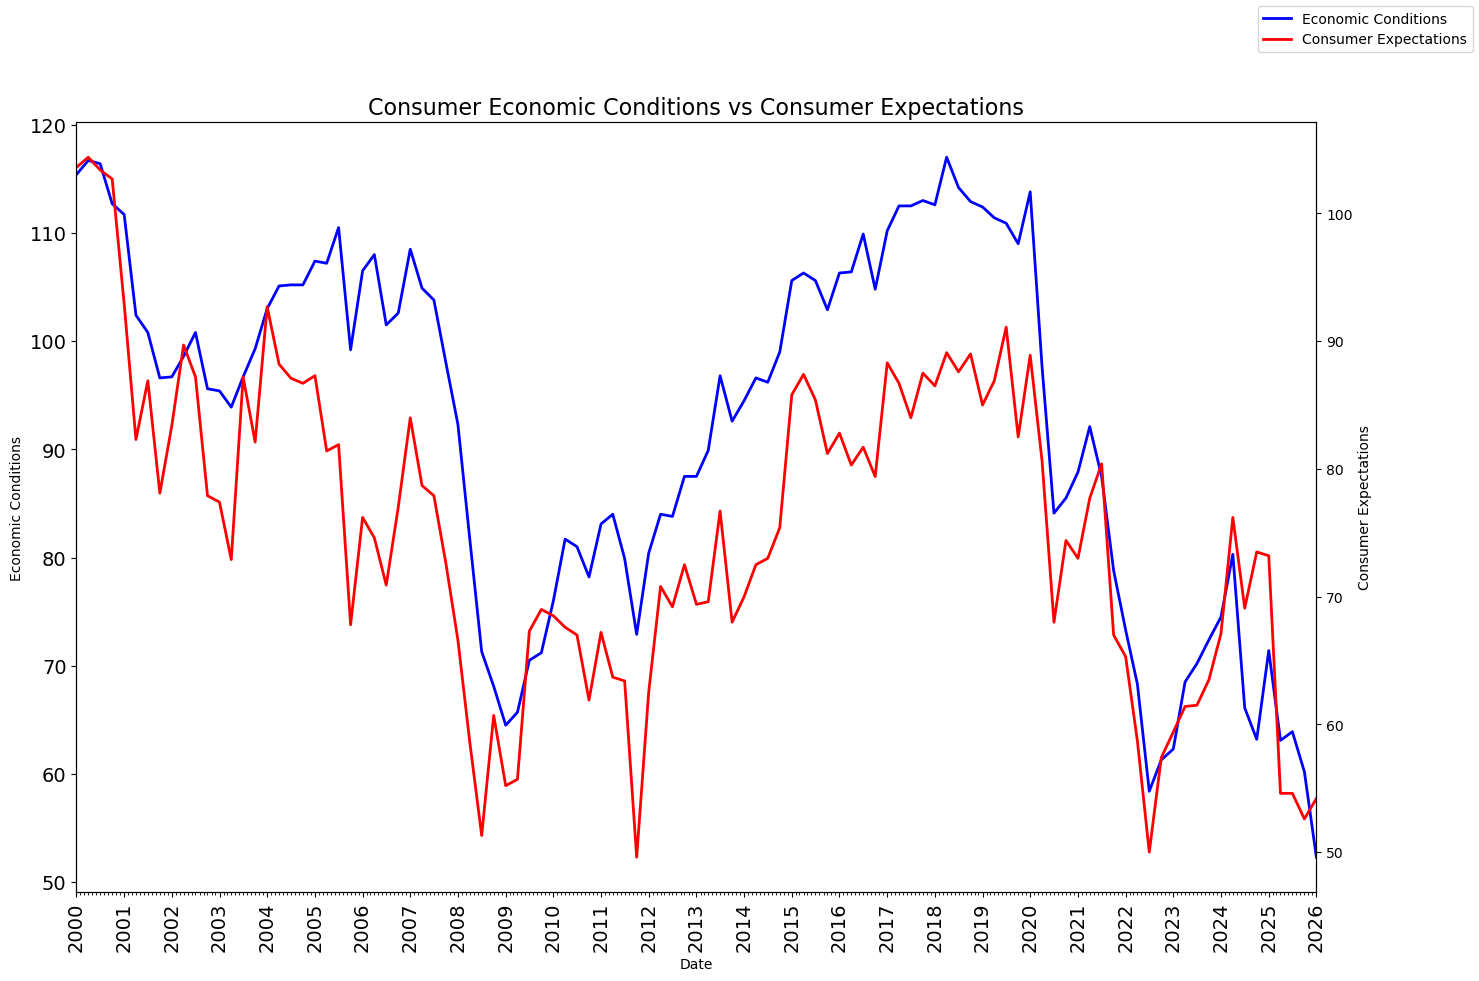

In [97]:
## Plot
plt.figure(figsize=(16,10))
plt.xticks(fontsize=14, rotation = 90)
plt.yticks(fontsize=14)

ax1 = plt.gca()
ax2 = ax1.twinx()

ax1.plot(merged_df["Date"],
         merged_df["Economic_Conditions_index"],
         color="Blue",
         linewidth=2,
         label="Economic Conditions")
ax2.plot(merged_df["Date"],
         merged_df["Consumer_Expectations_index"],
         color="Red",
         linewidth=2,
         label="Consumer Expectations")

    ## Adding in the date functionalities
Year = mdates.YearLocator()
Months = mdates.MonthLocator()
Years_FMT = mdates.DateFormatter('%Y')

ax1.xaxis.set_major_locator(Year)
ax1.xaxis.set_minor_locator(Months)
ax1.xaxis.set_major_formatter(Years_FMT)





ax1.set_xlabel("Date")
ax1.set_ylabel("Economic Conditions")
ax2.set_ylabel("Consumer Expectations")
plt.xlim(pd.Timestamp("2000-01-01"), pd.Timestamp("2026-01-01"))

plt.title("Consumer Economic Conditions vs Consumer Expectations", fontsize=16)
fig= plt.gcf()
fig.legend()
fig.show()